# Exercícios

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import graphviz

In [2]:
#pip install graphviz

## 1.

Carregue o conjunto de dados "breast_cancer" usando a função "load_breast_cancer()".

In [3]:
#load data
cancer = load_breast_cancer()

## 2.

Faça uma divisão treino/teste com os valores por omissão (treino=75%, teste=25%).

In [4]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
	cancer.data, cancer.target, stratify=cancer.target, random_state=0)

## 3.

Construa um modelo usando árvores de decisão com os valores por omissão. Verifique o nº de
folhas e a profundidade da árvore gerada. Calcule o desempenho sobre ambos os conjuntos.

In [5]:
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

exatidao_treino = tree.score(X_train, y_train)
exatidao_teste = tree.score(X_test, y_test)

print("Folhas:", tree.get_n_leaves())
print("Profundidade:", tree.get_depth())
print("Exatidão de treino:", exatidao_treino, "\nExatidão de teste:", exatidao_teste)

Folhas: 18
Profundidade: 5
Exatidão de treino: 1.0 
Exatidão de teste: 0.9020979020979021


## 4.

Crie um novo modelo, desta vez aplicando pre-pruning limitando a profundidade da árvore a 4
níveis. Calcule o desempenho sobre ambos os conjuntos para este novo modelo.

In [6]:
tree_pre_pruning = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_pre_pruning.fit(X_train, y_train)

exatidao_treino = tree_pre_pruning.score(X_train, y_train)
exatidao_teste = tree_pre_pruning.score(X_test, y_test)

print("Folhas:", tree_pre_pruning.get_n_leaves())
print("Profundidade:", tree_pre_pruning.get_depth())
print("Exatidão de treino:", exatidao_treino, "\nExatidão de teste:", exatidao_teste)

Folhas: 13
Profundidade: 4
Exatidão de treino: 0.9859154929577465 
Exatidão de teste: 0.9090909090909091


## 5.

A árvore pode ser visualizada utilizando a função 'export_graphviz()' do módulo
'sklearn.tree'. Esta função gera um ficheiro no formato '.dot' (formato de texto para guardar
grafos). Verifique os parâmetros da função.
A chamada de função indicada abaixo gera um ficheiro 'tree.dot', permite colorir os nós para
refletir a classe maioritária e utiliza o nome das classes e atributos para etiquetar a árvore:

export_graphviz(tree, out_file="tree.dot",

class_names=["malignant", "benign"],

feature_names=cancer.feature_names,

impurity=False, filled=True)

Visualize a árvore podada utilizando o módulo 'graphviz' e analise-a. Indique os caminhos que a
maioria dos exemplos segue.


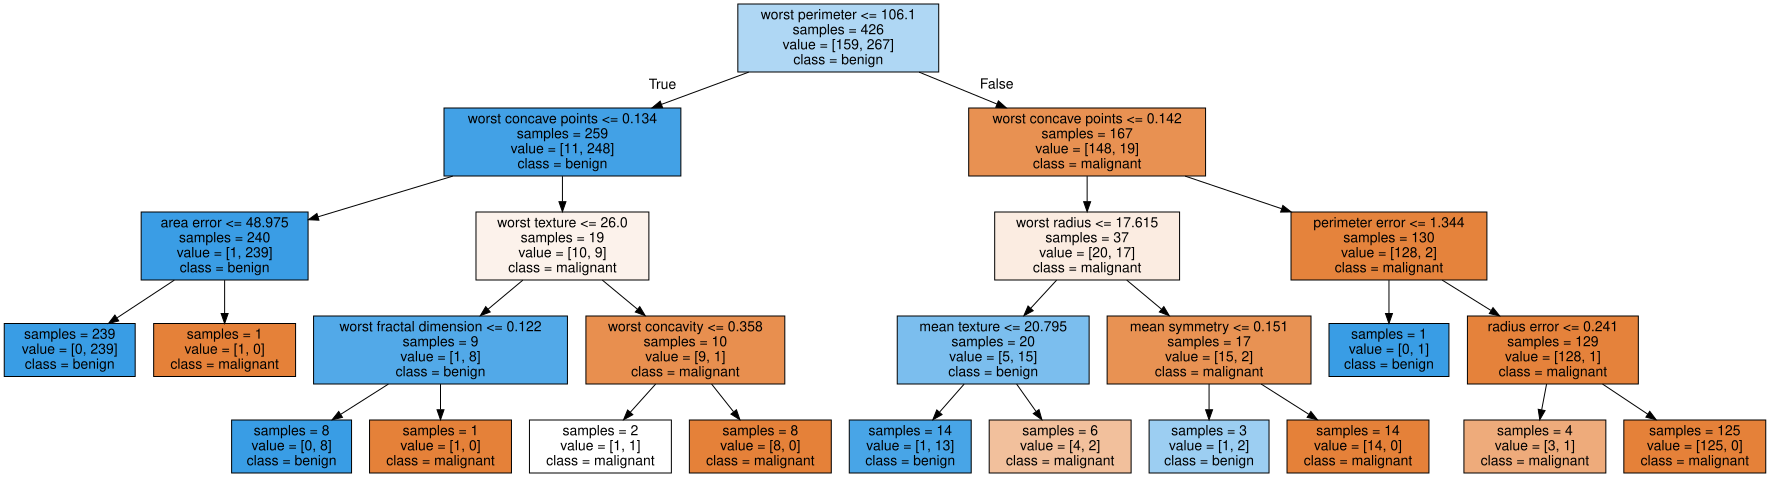

In [7]:
dot_data = export_graphviz(
    tree_pre_pruning,
    out_file=None,
    class_names=["malignant", "benign"],
    feature_names=cancer.feature_names,
    impurity=False,
    filled=True
)

graph = graphviz.Source(dot_data)
graph.render("tree_pre_pruning", format="png")  # gera ficheiro
graph

Na árvore de decisão podada, a maioria dos exemplos inicia o percurso no nó raiz, onde se avalia o atributo worst perimeter error. Quando este valor é baixo, os casos seguem para o ramo esquerdo, que conduz a novas divisões baseadas em atributos como worst concave points, area error e worst texture. Estes valores, quando reduzidos, levam a folhas que classificam os tumores como benignos, refletindo o padrão dominante no conjunto de dados. Assim, o caminho mais frequente é caracterizado por valores baixos nestes atributos, indicando tumores menos agressivos. Já os exemplos que apresentam valores elevados nestas medidas seguem pelos ramos direitos da árvore, onde atributos como worst fractal dimension e worst radius entram em jogo, conduzindo a classificações como malignos

## 6.

Outra forma de analisar uma árvore de decisão é calcular a importância dos atributos. Esta medida
avalia quão importante é cada atributo na decisão feita pela árvore e varia entre 0 e 1, com 0 a
indicar que o atributo não é usado e 1 a indicar que o atributo prevê a classe perfeitamente (as
importâncias somam sempre 1). A importância dos atributos é guardada no atributo
'feature_importances_' do modelo gerado.
Apresente um gráfico de barras que mostre a importância de cada atributo.

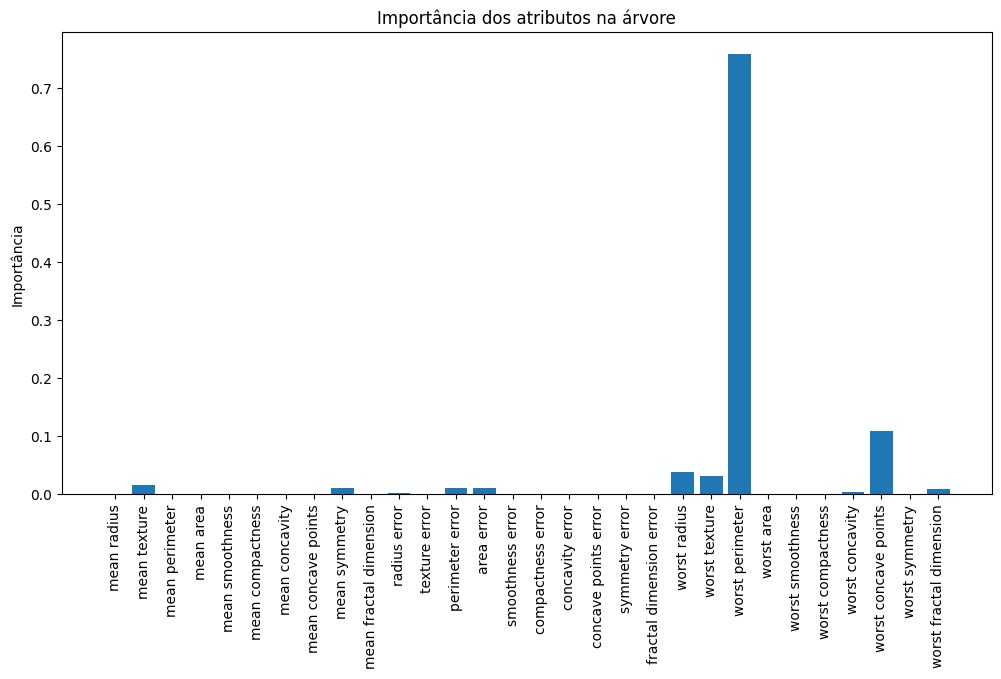

In [8]:
importances = tree_pre_pruning.feature_importances_
plt.figure(figsize=(12,6))
plt.bar(range(len(importances)), importances)
plt.xticks(range(len(importances)), cancer.feature_names, rotation=90)
plt.ylabel("Importância")
plt.title("Importância dos atributos na árvore")
plt.show()